# BANK TERM DEPOSIT SUBSCRIPTION PREDICTION

## Problem Statement:

Predict whether a client will subscribe to a bank term deposit or not.  
And Answer the following Questions:
1) Which customers should be targetted?
2) Which customers should NOT be targetted?
3) What characteristics define high-propensity customers?
4) Which market channel is the most effective?
5) How  many contacts maximize conversions before diminishing returns occur?
6) Which Customer segments produce the highest ROI?

## Dataset:

https://www.kaggle.com/datasets/sushant097/bank-marketing-dataset-full/data

## Features:


1) age: Age of the client (numeric)
2) job: Type of job (categorical: "admin.", "blue-collar", "entrepreneur", etc.)  
3) marital: Marital status (categorical: "married", "single", "divorced")  
4) education: Level of education (categorical: "primary", "secondary", "tertiary", "unknown")  
5) default: Has credit in default? (categorical: "yes", "no")  
6) balance: Average yearly balance in euros (numeric)  
7) housing: Has a housing loan? (categorical: "yes", "no")  
8) loan: Has a personal loan? (categorical: "yes", "no")  
9) contact: Type of communication contact (categorical: "unknown", "telephone", "cellular")  
10) day: Last contact day of the month (numeric, 1-31)  
11) month: Last contact month of the year (categorical: "jan", "feb", "mar", …, "dec")  
12) duration: Last contact duration in seconds (numeric)  
13) campaign: Number of contacts performed during this campaign (numeric)  
14) pdays: Number of days since the client was last contacted from a previous campaign (numeric; -1 means the client was not previously contacted)  
15) previous: Number of contacts performed before this campaign (numeric)  
16) poutcome: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")  
17) y: The target variable, whether the client subscribed to a term deposit (binary: "yes", "no")  

## I. Loading and set-up:

In [1]:
%pip install seaborn
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer       
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score


sns.set_theme(style="whitegrid", palette = 'Set2')

from scipy.stats import zscore


In [3]:
sns.set_theme(style="whitegrid", palette='Set2')

In [4]:
data = pd.read_csv("bank-full.csv", sep=';')
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## II. Dataset Overview

In [5]:
data.shape

(45211, 17)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [7]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
(data == 'unknown').sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

In [11]:
for col in data.select_dtypes('object'):
    print(col)
    data[col] = (data[col].astype(str).str.strip().str.upper())
    print(data[col].unique()) 

job
<ArrowStringArray>
[   'MANAGEMENT',    'TECHNICIAN',  'ENTREPRENEUR',   'BLUE-COLLAR',
       'UNKNOWN',       'RETIRED',        'ADMIN.',      'SERVICES',
 'SELF-EMPLOYED',    'UNEMPLOYED',     'HOUSEMAID',       'STUDENT']
Length: 12, dtype: str
marital
<ArrowStringArray>
['MARRIED', 'SINGLE', 'DIVORCED']
Length: 3, dtype: str
education
<ArrowStringArray>
['TERTIARY', 'SECONDARY', 'UNKNOWN', 'PRIMARY']
Length: 4, dtype: str
default
<ArrowStringArray>
['NO', 'YES']
Length: 2, dtype: str
housing
<ArrowStringArray>
['YES', 'NO']
Length: 2, dtype: str
loan
<ArrowStringArray>
['NO', 'YES']
Length: 2, dtype: str
contact
<ArrowStringArray>
['UNKNOWN', 'CELLULAR', 'TELEPHONE']
Length: 3, dtype: str
month
<ArrowStringArray>
['MAY', 'JUN', 'JUL', 'AUG', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR', 'APR',
 'SEP']
Length: 12, dtype: str
poutcome
<ArrowStringArray>
['UNKNOWN', 'FAILURE', 'OTHER', 'SUCCESS']
Length: 4, dtype: str
y
<ArrowStringArray>
['NO', 'YES']
Length: 2, dtype: str


C:\Users\asmis\AppData\Local\Temp\ipykernel_23684\1746741275.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes('object'):


### Inference:
1) No null values. All 45211 records are non-null.
2) There are no duplicate records.
3) The maximum range for age is realistic (18 to 95)
4) No need to handle the 'unknown' as null since they affect only the self-declarable features and poutcome, which has actual busincess insight rather than just no value.
5) 'other' in poutcome can be considered as the customers not fitting the success or failure criteria of the campaign. No need to drop for now.
6) 'duration' feature is problematic since it causes target leakage.

In [12]:
cat_cols = ['marital', 'job', 'month']
for col in cat_cols:
    data[col] = (data[col].astype(str).str.strip().str.upper())

In [13]:
data['age_band'] = pd.cut(
    data['age'], 
    bins=[18, 29, 44, 59, 100], 
    labels=['YOUNG-ADULT', 'MIDDLE-AGED', 'LATE-MIDDLE-AGED', 'SENIOR'],
    include_lowest=True
).astype('object')

In [14]:
data['age_band'].value_counts(normalize=True) * 100

age_band
MIDDLE-AGED         53.690474
LATE-MIDDLE-AGED    30.700493
YOUNG-ADULT         11.663091
SENIOR               3.945942
Name: proportion, dtype: float64

In [15]:
data['balance'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
90%        3574.000000
95%        5768.000000
99%       13164.900000
max      102127.000000
Name: balance, dtype: float64

In [16]:
data['tier'] = pd.cut(
    data['balance'], 
    bins=[-10000, 0, 500, 1500, 6000, 2000000], 
    labels=['NEGATIVE', 'LOW', 'MIDDLE', 'HIGH', 'PREMIUM'],
).astype('object')

In [17]:
data['tier'].value_counts(normalize=True) * 100

tier
LOW         36.241180
MIDDLE      23.558426
HIGH        19.435536
NEGATIVE    16.102276
PREMIUM      4.662582
Name: proportion, dtype: float64

In [18]:
#data['previously_contacted'] = np.where(datam['pdays'] == -1,'NO','YES')

In [19]:
#datam['previous_success'] = np.where(datam['poutcome'] == 'SUCCESS',1,0)

## III. EDA

In [20]:
data.groupby('contact')['y'].value_counts(normalize=True)

contact    y  
CELLULAR   NO     0.850811
           YES    0.149189
TELEPHONE  NO     0.865795
           YES    0.134205
UNKNOWN    NO     0.959293
           YES    0.040707
Name: proportion, dtype: float64

In [21]:
data[data['poutcome'] == 'UNKNOWN']['pdays'].describe()

count    36959.000000
mean        -0.962039
std          3.778887
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        528.000000
Name: pdays, dtype: float64

### Inferences:
The 'unknown' values actually hold significant business meaning and cannot be dismissed as just null values.  
1) 'unknown' job or education means that the data wasn't reported/collected/declared/etc. Not necessarily an issue.
2) 'unknown' contact could mean that if the customer wasn't contacted via cellular or telephone. The customer could be exposed to advertisements/word of mouth/etc.
3) 'unknown' poutcome is valid when we reason taht if there were no previous campaigns then there would be an unknown outcome.

### Fig 1: Dataset Imbalance

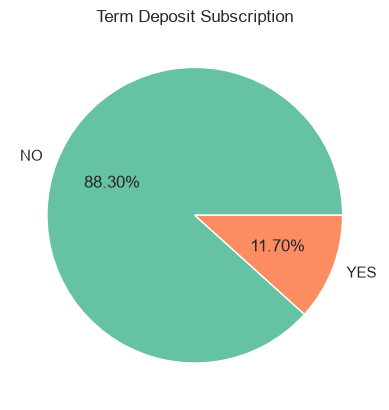

In [22]:
data['y'].value_counts().plot(
    kind='pie',
    autopct='%.2f%%',
    ylabel=''
)

plt.title('Term Deposit Subscription')
plt.show()

### Inference:
Only 11.70% of customer are subscribed.The dataset is highly imbalanced.

### Q2) Who should we target? (building a customer profile)

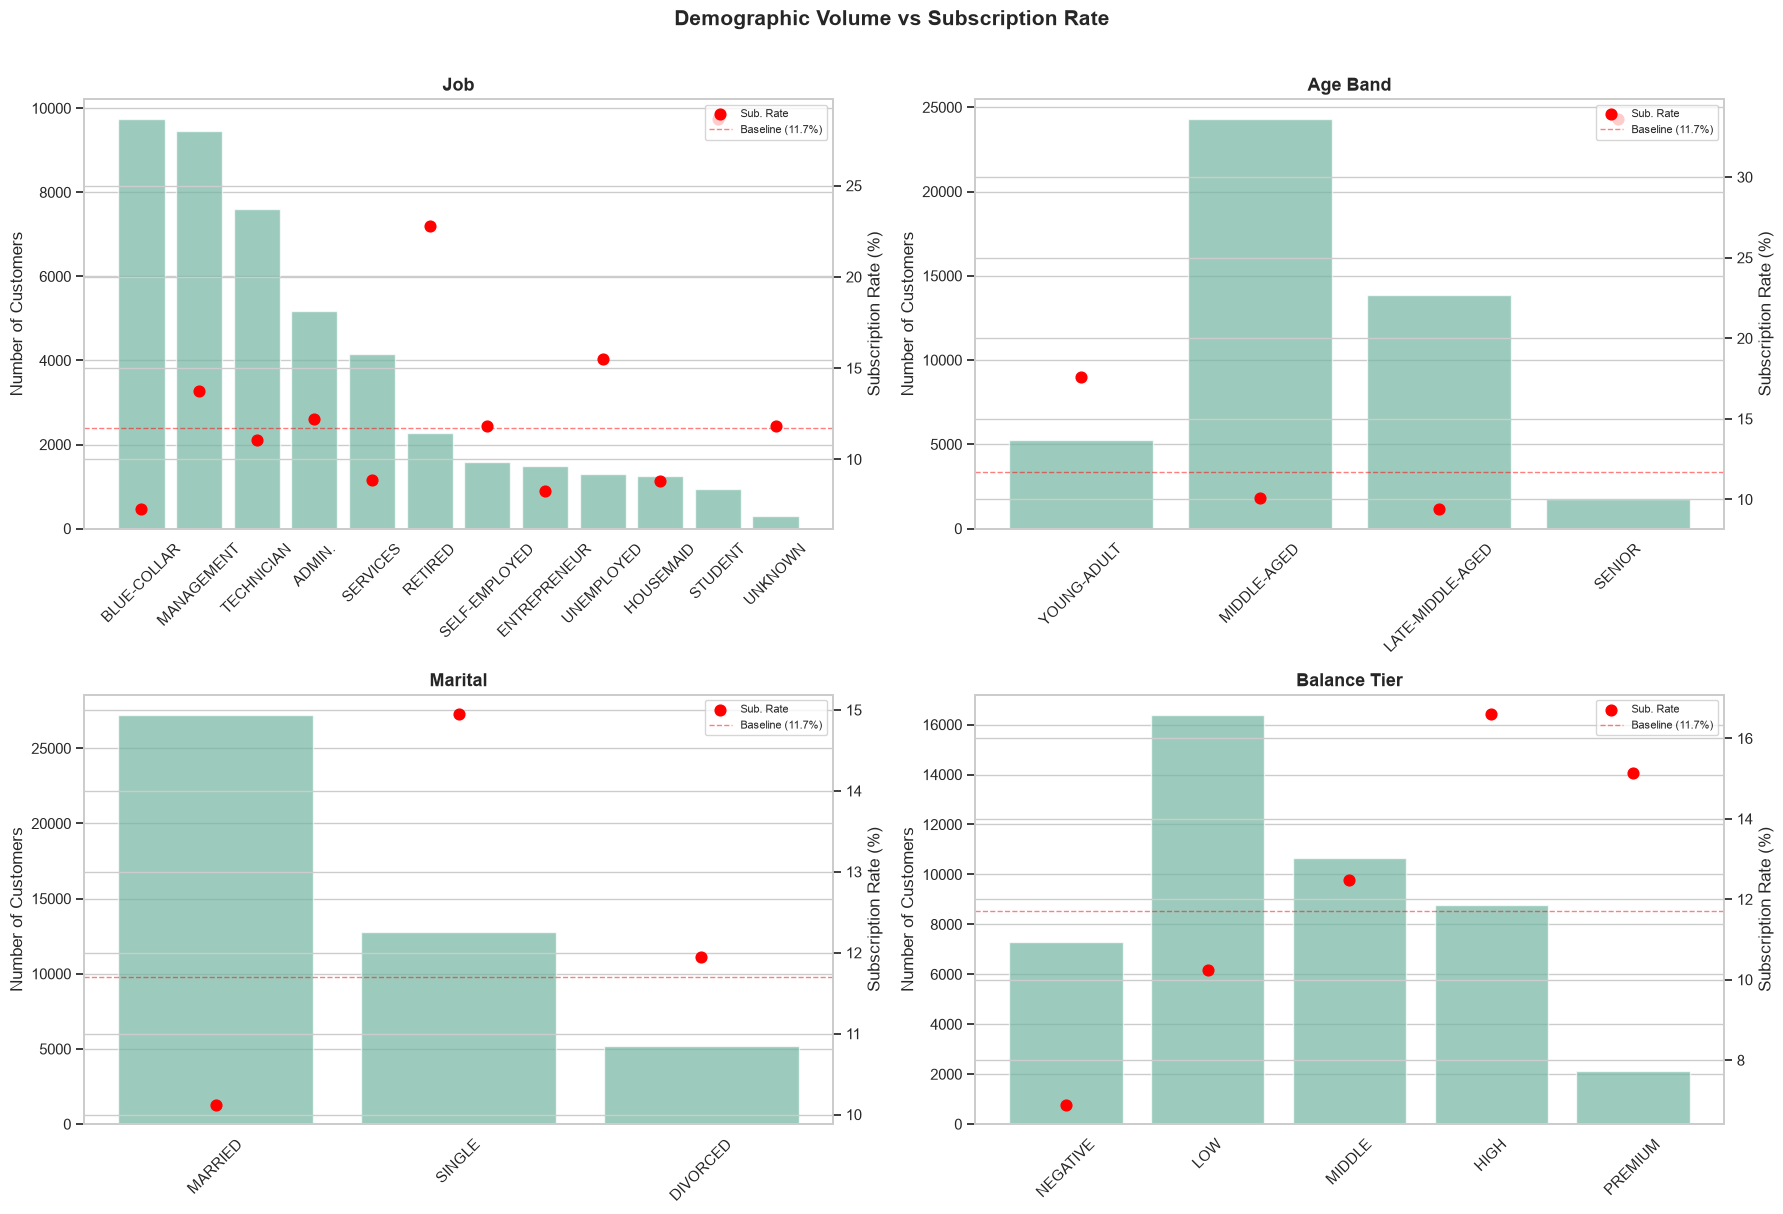

In [23]:
segments = {
    'Job':('job','total', False),
    'Age Band':('age_band','age_band',True),
    'Marital':('marital','total',False),
    'Balance Tier': ('tier','tier',True),
}

fixed_orders = {'age_band':['YOUNG-ADULT', 'MIDDLE-AGED', 'LATE-MIDDLE-AGED', 'SENIOR'],
                'tier':['NEGATIVE', 'LOW', 'MIDDLE', 'HIGH', 'PREMIUM']}

baseline = (data['y'] == 'YES').mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (title, (col, sort_by, sort_asc)) in enumerate(segments.items()):
    stats = (
        data.groupby(col, observed=True)['y']
        .agg(total='count', subscribers=lambda x: (x == 'YES').sum())
        .assign(rate=lambda d: d['subscribers'] / d['total'] * 100)
        .reset_index()
    )

    if col in fixed_orders:
        stats[col] = pd.Categorical(stats[col], categories=fixed_orders[col], ordered=False)
        stats = stats.sort_values(col)
    else:
        stats = stats.sort_values('total', ascending=False)

    ax1 = axes[i]
    ax2 = ax1.twinx()

    sns.barplot(data=stats, x=col, y='total', ax=ax1, alpha=0.7)
    ax2.scatter(x=range(len(stats)), y=stats['rate'], color='red', s=60, zorder=5, label='Sub. Rate')
    ax2.axhline(baseline, color='red', linestyle='--', linewidth=1,
                alpha=0.5, label=f'Baseline ({baseline:.1f}%)')

    ax1.set_title(title, fontsize=13, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Number of Customers')
    ax2.set_ylabel('Subscription Rate (%)')
    ax1.tick_params(axis='x', rotation=45)
    ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Demographic Volume vs Subscription Rate', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Fig 2.1: Subscription rate by age group 
Inference:
1) The largest part of our customer base (middle-aged customers) have a low tendency to stay subscribed. This maybe because they have less spare cash for term deposits due to mortgage payments, expenses, etc.
2) The smaller but more loyal Senior customer base is fairly devoted. This is most likely due to retirement funds, lower risk tolerance, and a preference for fixed-income products like term deposits since they no longer actively participate in the workforce.

#### Fig 2.2: Subscription rate by job
Inference:
1) We can see that Students (28.7%) and Retirees (22.8%) are more likely to stay subscribed even if they make up less of the customer base.
2) Blue-collar workers, on the other hand, are the largest part of the customer basse, but they have the lowest rate of staying subscribed (7.3%).
3) Unknown values (assumed to be undeclared employment status).

#### Fig 2.3: Subscription rate by Balance Tier
Inference:
Although customer balances vary across the population, the subscription rates are relatively consistent across balance tiers. Other factors likely play a more important role in influencing customer decisions.

#### 2.4. Marital Status and Subscription Rate

### Q3) When should campaigns run?

### Fig 3: Campaign volume vs Subscription Rate over the months

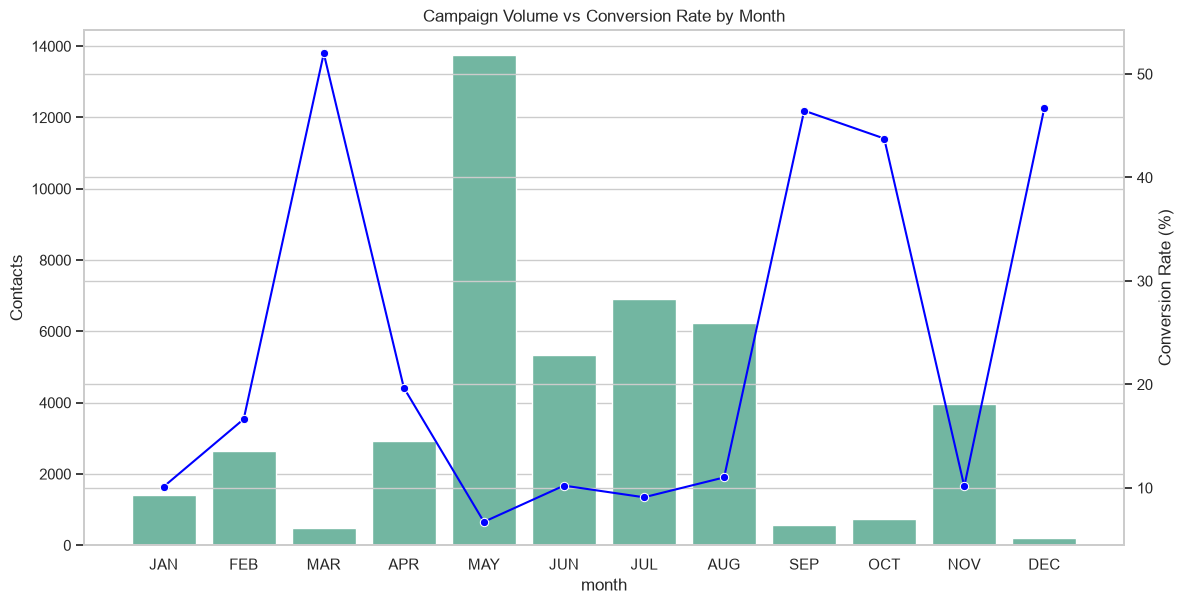

In [24]:
month_order =['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
eda3_2 = pd.crosstab(data['month'], data['y'])

eda3_2['total'] = (eda3_2['YES'] + eda3_2['NO'])

eda3_2['conversion_rate'] = (eda3_2['YES'] / eda3_2['total'] * 100)

eda3_2 = eda3_2.reset_index()
eda3_2['month'] = pd.Categorical(eda3_2['month'],categories=month_order,ordered=True)
eda3_2 = eda3_2.sort_values('month')

fig, ax1 = plt.subplots(figsize=(12,6))

sns.barplot(data=eda3_2,x='month',y='total',ax=ax1)
ax1.set_ylabel('Contacts')
ax2 = ax1.twinx()

sns.lineplot(data=eda3_2,x='month',y='conversion_rate',marker='o', color="blue",ax=ax2)
    
ax2.set_ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.title('Campaign Volume vs Conversion Rate by Month')
plt.show()

### Inference:
1) We can see that although the colume of calls made in March was the lowest, it had the highest conversion rate.
2) Whereas, a large call volume in May had the lowest conversion rate.

### EDA 4

In [25]:
eda4 = (data.groupby('contact')
      .agg(customers=('y', 'count'),subscriptions=('y', lambda x: (x == 'YES').sum()))
      .reset_index())

eda4['subscription_rate'] = (eda4['subscriptions']/eda4['customers']* 100)
eda4.sort_values('subscription_rate',ascending=False,inplace=True)

eda4

,contact,customers,subscriptions,subscription_rate
0,CELLULAR,29285,4369,14.918900
1,TELEPHONE,2906,390,13.420509
2,UNKNOWN,13020,530,4.070661


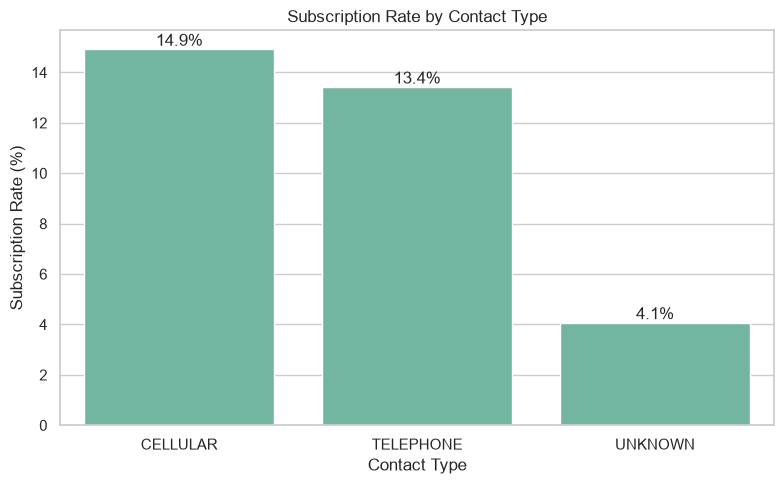

In [26]:
plt.figure(figsize=(8,5))

ax = sns.barplot(data=eda4,x='contact',y='subscription_rate')

plt.title('Subscription Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Subscription Rate (%)')

for p in ax.patches:ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),ha='center',va='bottom')

plt.tight_layout()
plt.show()

### Inference: 
1) The most successful attempts have been via Cellular. Mostly due to the increased adoption of phones in the older and younger age bands that have the most positive outcome.

### !!!!!!Q4) how many times should we contact a customer before it becomes ineffective?

In [27]:
eda4_1 = (data.groupby('previous')['y'].apply(lambda x: (x=='YES').mean()*100).reset_index(name='rate'))

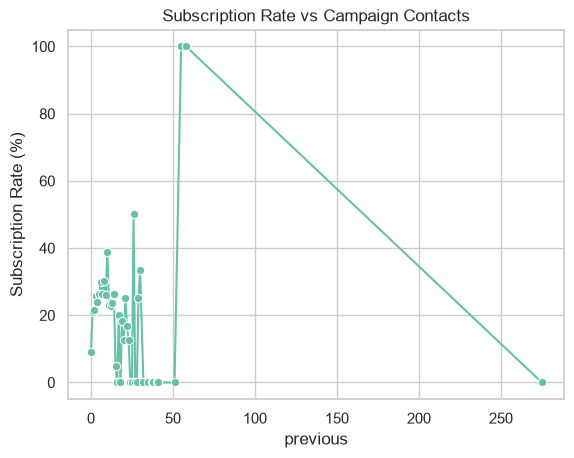

In [28]:
sns.lineplot(data=eda4_1,x='previous',y='rate',marker='o')

plt.title('Subscription Rate vs Campaign Contacts')
plt.ylabel('Subscription Rate (%)')
plt.show()

In [29]:
data['campaign'].value_counts().sort_index().head(10)

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
Name: count, dtype: int64

In [30]:
plt.figure(figsize=(10,5))
sns.lineplot(datA=eda4_1,x='campaign',y='rate',marker='o')
plt.title('Subscription Rate vs Number of Campaign Contacts')
plt.xlabel('Number of Contacts in Current Campaign')
plt.ylabel('Subscription Rate (%)')

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `campaign` for `x`. Value is a string, but `data` was not passed.

<Figure size 1000x500 with 0 Axes>

#### Inference:


### !!!!!!!Q5) Does the outcome of the previous campaign affect future success?

In [31]:
eda5 = (data.groupby('poutcome')
      .agg(customers=('y', 'count'),subscriptions=('y', lambda x: (x == 'YES').sum()))
        .reset_index())

eda5['subscription_rate'] = (eda5['subscriptions']/ eda5['customers']* 100)
eda5.sort_values('subscription_rate',ascending=False, inplace=True)

eda5

,poutcome,customers,subscriptions,subscription_rate
2,SUCCESS,1511,978,64.725347
1,OTHER,1840,307,16.684783
0,FAILURE,4901,618,12.609671
3,UNKNOWN,36959,3386,9.161503


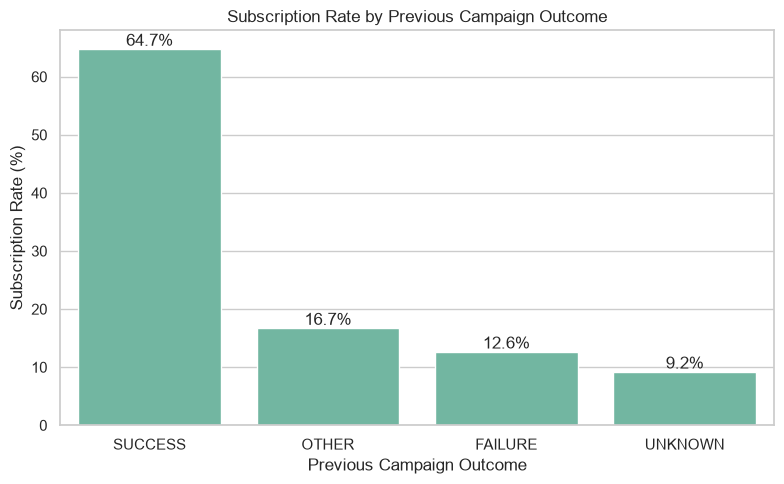

In [32]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=eda5,
    x='poutcome',
    y='subscription_rate'
)

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### !!!!!!Q6) previously contacted vs subcription

In [33]:
data['previously_contacted'] = np.where(data['pdays'] == -1,'NO','YES')
eda4_3 = (data.groupby('previously_contacted')['y'].apply(lambda x: (x=='yes').mean()*100).reset_index(name='rate'))

C:\Users\asmis\AppData\Local\Temp\ipykernel_23684\1334860092.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda4_3,x='previously_contacted',y='rate', palette={'NO': 'red', 'YES': 'green'})


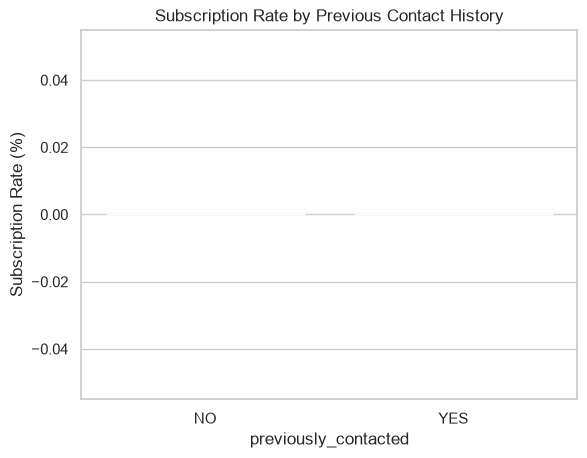

In [34]:
sns.barplot(data=eda4_3,x='previously_contacted',y='rate', palette={'NO': 'red', 'YES': 'green'})

plt.title('Subscription Rate by Previous Contact History')
plt.ylabel('Subscription Rate (%)')
plt.show()

## IV. Feature Engineering and Preprocessing

In [35]:
#Removed features that may cause target leakage:('campaign', 'duration')
datam = data.copy()
datam = datam.drop(columns=['campaign', 'duration', 'age_band', 'tier', 'previously_contacted'])
datam

,age,job,marital,education,default,balance,housing,loan,contact,day,month,pdays,previous,poutcome,y
0,58,MANAGEMENT,MARRIED,TERTIARY,NO,2143,YES,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN,NO
1,44,TECHNICIAN,SINGLE,SECONDARY,NO,29,YES,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN,NO
2,33,ENTREPRENEUR,MARRIED,SECONDARY,NO,2,YES,YES,UNKNOWN,5,MAY,-1,0,UNKNOWN,NO
3,47,BLUE-COLLAR,MARRIED,UNKNOWN,NO,1506,YES,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN,NO
4,33,UNKNOWN,SINGLE,UNKNOWN,NO,1,NO,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,TECHNICIAN,MARRIED,TERTIARY,NO,825,NO,NO,CELLULAR,17,NOV,-1,0,UNKNOWN,YES
45207,71,RETIRED,DIVORCED,PRIMARY,NO,1729,NO,NO,CELLULAR,17,NOV,-1,0,UNKNOWN,YES
45208,72,RETIRED,MARRIED,SECONDARY,NO,5715,NO,NO,CELLULAR,17,NOV,184,3,SUCCESS,YES
45209,57,BLUE-COLLAR,MARRIED,SECONDARY,NO,668,NO,NO,TELEPHONE,17,NOV,-1,0,UNKNOWN,NO


In [36]:
Y = datam['y'].map({'NO':0,'YES':1})
X = datam.drop('y', axis=1)

In [37]:
Y.tail(5)

45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, dtype: int64

In [38]:
X.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
pdays        int64
previous     int64
poutcome       str
dtype: object

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state = 42, stratify=Y)
print(f'Dataset: {len(datam)} samples, {X.shape[1]} features, {Y.nunique()} classes')
print(f'Train: {len(X_train)} samples')
print(f'Test: {len(X_test)} samples')
X.head()

Dataset: 45211 samples, 14 features, 2 classes
Train: 33908 samples
Test: 11303 samples


,age,job,marital,education,default,balance,housing,loan,contact,day,month,pdays,previous,poutcome
0,58,MANAGEMENT,MARRIED,TERTIARY,NO,2143,YES,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN
1,44,TECHNICIAN,SINGLE,SECONDARY,NO,29,YES,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN
2,33,ENTREPRENEUR,MARRIED,SECONDARY,NO,2,YES,YES,UNKNOWN,5,MAY,-1,0,UNKNOWN
3,47,BLUE-COLLAR,MARRIED,UNKNOWN,NO,1506,YES,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN
4,33,UNKNOWN,SINGLE,UNKNOWN,NO,1,NO,NO,UNKNOWN,5,MAY,-1,0,UNKNOWN


In [ ]:
class feat_engineer(BaseEstimator, TransformerMixin):

        

In [41]:
NUM_FEAT = ['age', 'balance', 'day','previous','month_num', 'month_sin', 'month_cos','contacted_before']
CAT_FEAT= ['job', 'marital', 'education', 'default', 'housing','loan', 'contact', 'poutcome']

tree_prep = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT)], remainder='passthrough')

NUM_FEAT_NO_BAL = [f for f in NUM_FEAT if f != 'balance']

lr_prep = ColumnTransformer(transformers=[('num', RobustScaler(), NUM_FEAT_NO_BAL), 
                                          ('bal', PowerTransformer(method='yeo-johnson'), ['balance']),
                                          ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT)])

In [ ]:
scale_pos = (Y_train == 0).sum() / (Y_train == 1).sum()

pipelines = {
    'Logistic Regression': Pipeline([('fe', feat_engineer()), 
                                     ('prep', lr_prep), 
                                     ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))]),
    'Random Forest': Pipeline([('fe', feat_engineer()), 
                                     ('prep', tree_prep), 
                                     ('model', RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=10, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('fe', feat_engineer()), 
                                     ('prep', tree_prep), 
                                     ('model', XGBClassifier(scale_pos_weight=scale_pos, n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.08, eval_metric='logloss', random_state=42, n_jobs=-1))])
}

In [43]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring=['roc_auc', 'f1', 'precision', 'recall']
cv_results = {}

In [44]:
for name, pipe in pipelines.items():
    print(f"Training {name}...")
    scores = cross_validate(pipe, X_train, Y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: scores[f'test_{m}'].mean() for m in scoring}

cv_df = pd.DataFrame(cv_results).T.sort_values('roc_auc', ascending=False)
print("\n── Cross-Validation Results ────────────────────────────")
print(cv_df.round(4))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

── Cross-Validation Results ────────────────────────────
                     roc_auc      f1  precision  recall
Random Forest         0.7909  0.4453     0.3578  0.5896
XGBoost               0.7824  0.4137     0.3091  0.6252
Logistic Regression   0.7420  0.3375     0.2283  0.6468


## VII. Modelling

In [47]:
best_name = cv_df.index[0]
best_pipe = pipelines[best_name]

print(f"Best model from CV: {best_name}")
print("Fitting on full training set...")

best_pipe.fit(X_train, Y_train)

y_pred       = best_pipe.predict(X_test)
y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(Y_test, y_pred_proba):.4f}")
print(f"Test F1:      {f1_score(Y_test, y_pred):.4f}")
print()
print(classification_report(Y_test, y_pred, target_names=['No Subscribe', 'Subscribe']))


Best model from CV: Random Forest
Fitting on full training set...

Test ROC-AUC: 0.7978
Test F1:      0.4516

              precision    recall  f1-score   support

No Subscribe       0.94      0.86      0.90      9981
   Subscribe       0.36      0.61      0.45      1322

    accuracy                           0.83     11303
   macro avg       0.65      0.73      0.67     11303
weighted avg       0.87      0.83      0.85     11303



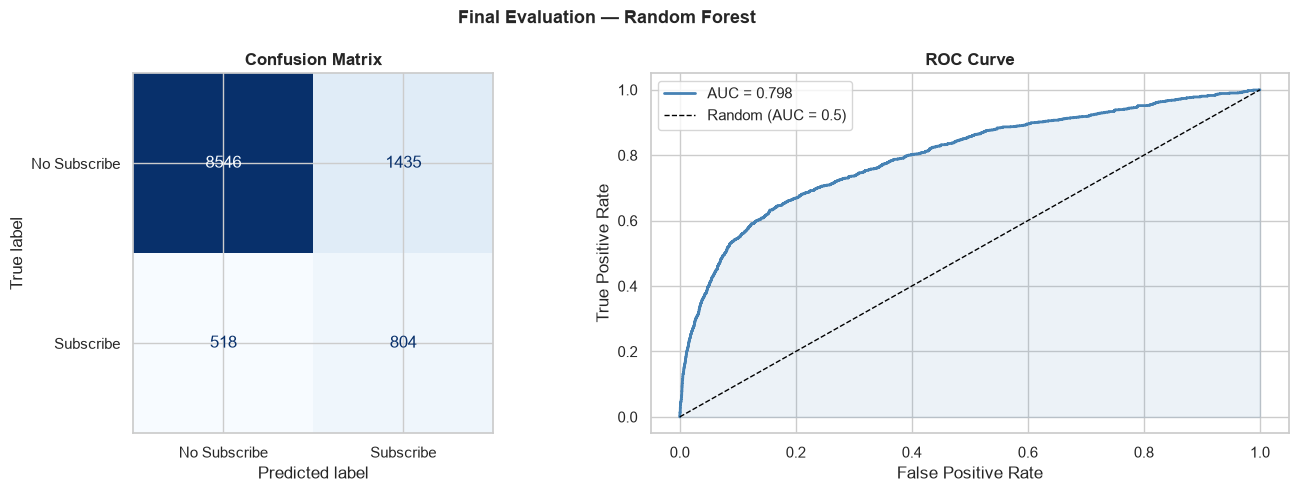

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Subscribe', 'Subscribe']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
auc_score   = roc_auc_score(Y_test, y_pred_proba)
axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle(f'Final Evaluation — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [51]:
# Score every customer in training+test (for illustration)
# In production you'd score your new, unseen customer list here
all_scores = best_pipe.predict_proba(X)[:, 1]

scored = X.copy()
scored['propensity_score'] = all_scores
scored['actual_y']         = Y.values

# Tier customers into priority segments
scored['priority'] = pd.cut(
    scored['propensity_score'],
    bins=[0, 0.15, 0.35, 0.60, 1.0],
    labels=['DO NOT CONTACT', 'LOW PRIORITY', 'MEDIUM PRIORITY', 'HIGH PRIORITY']
)

summary = (
    scored.groupby('priority', observed=True)
    .agg(
        customer_count=('propensity_score', 'count'),
        avg_score=('propensity_score', 'mean'),
        actual_sub_rate=('actual_y', 'mean')
    )
    .assign(pct_of_base=lambda d: d['customer_count'] / d['customer_count'].sum() * 100)
    .reset_index()
)

print(summary.round(3).to_string(index=False))


       priority  customer_count  avg_score  actual_sub_rate  pct_of_base
 DO NOT CONTACT             800      0.137            0.004        1.769
   LOW PRIORITY           19502      0.254            0.027       43.136
MEDIUM PRIORITY           18860      0.432            0.096       41.716
  HIGH PRIORITY            6049      0.759            0.489       13.379


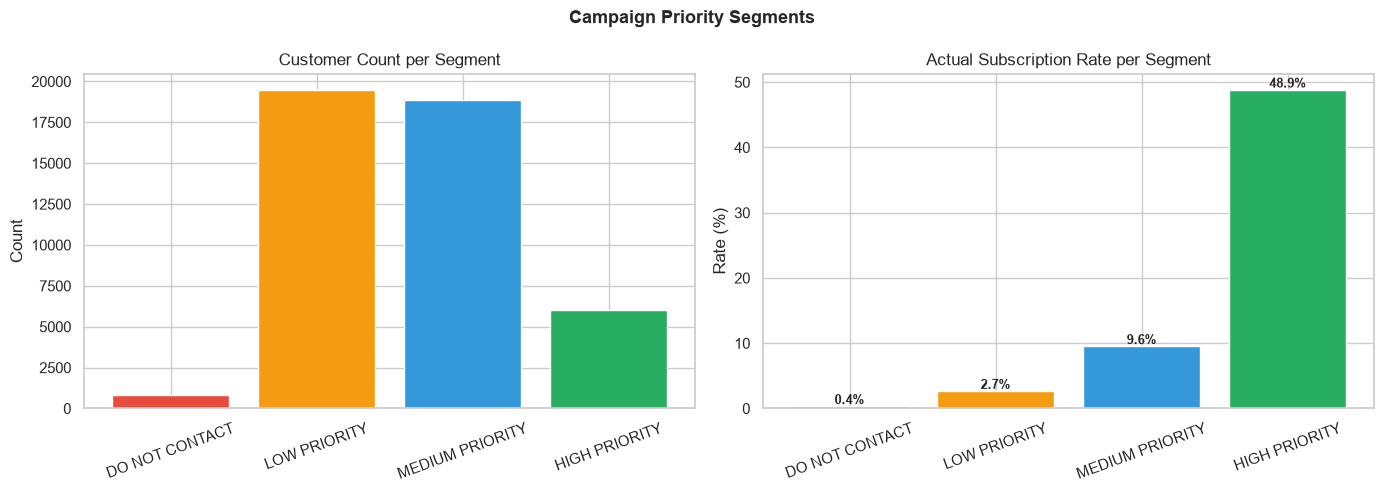


Campaign Recommendation:
  HIGH PRIORITY     → Call immediately via Cellular, max 3 attempts
  MEDIUM PRIORITY   → Call via Cellular, max 2 attempts
  LOW PRIORITY      → Digital/mail only, no outbound calls
  DO NOT CONTACT    → Suppress from campaign entirely


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_colors = {
    'DO NOT CONTACT': '#E74C3C',
    'LOW PRIORITY':   '#F39C12',
    'MEDIUM PRIORITY':'#3498DB',
    'HIGH PRIORITY':  '#27AE60'
}
colors = [seg_colors[s] for s in summary['priority']]

axes[0].bar(summary['priority'], summary['customer_count'], color=colors, edgecolor='white')
axes[0].set_title('Customer Count per Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(summary['priority'], summary['actual_sub_rate'] * 100, color=colors, edgecolor='white')
axes[1].set_title('Actual Subscription Rate per Segment')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[1].patches, summary['actual_sub_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Campaign Priority Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCampaign Recommendation:")
print("  HIGH PRIORITY     → Call immediately via Cellular, max 3 attempts")
print("  MEDIUM PRIORITY   → Call via Cellular, max 2 attempts")
print("  LOW PRIORITY      → Digital/mail only, no outbound calls")
print("  DO NOT CONTACT    → Suppress from campaign entirely")
